In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

## OB

2021-07-15-DpOBEM-N2_OB None
2021-07-15-DpOBEM-N2_OB
2021-07-15-DpOBEM-N2_OB None
2021-07-16-DpOBEM-N3_OB
2021-07-16-DpOBEM-N3_OB None
2021-12-10-DpOBEM-N4_OB
2021-12-10-DpOBEM-N4_OB None
2021-12-31-DpOBEM-N7_OB
2021-12-31-DpOBEM-N7_OB None
2022-02-13-DpOBEM-N10_OB
2022-02-13-DpOBEM-N10_OB None
2022-02-20-DpOBEM-N11_OB
2022-02-20-DpOBEM-N11_OB None
2021-02-05-DpOBEM-JH9_OB
2021-02-05-DpOBEM-JH9_OB None
2021-03-18-DpOBEM-JH10_OB
2021-03-18-DpOBEM-JH10_OB None
2021-03-19-DpOBEM-JH10_OB
2021-03-19-DpOBEM-JH10_OB None
2021-04-02-DpOBEM-JH11_OB
2021-04-02-DpOBEM-JH11_OB None
2021-04-03-DpOBEM-JH11_OB
2021-04-03-DpOBEM-JH11_OB None
2021-05-01-DpOBEM-JH13_OB
2021-05-01-DpOBEM-JH13_OB None
2021-05-22-DpOBEM-JH14_OB
2021-05-22-DpOBEM-JH14_OB None
2021-09-15-DpOBEM-JH20_OB
2021-09-15-DpOBEM-JH20_OB None
2021-09-17-DpOBEM-JH20_OB
2021-09-17-DpOBEM-JH20_OB None
2021-09-18-DpOBEM-JH20_OB
2021-09-18-DpOBEM-JH20_OB None
2021-07-30-DpOBEM-JH17_OB
2021-07-30-DpOBEM-JH17_OB None
2021-07-31-DpOBEM-JH17_O

C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(


F:\FMI_tachyon_hubo\Dp_manifold\juvenile_dataset\data\OB\spike_prob_long\per_odor_aligned\PN\index_formatted\firing_rate\pattern_correlation\window_38to63\cross_trial_similarity.pkl


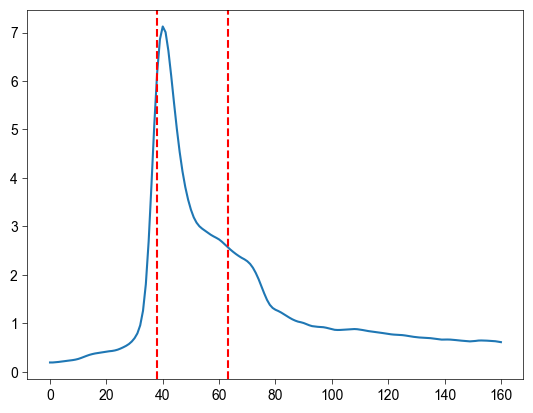

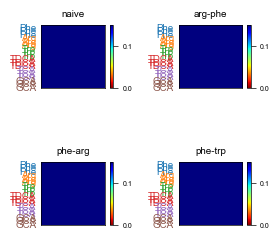

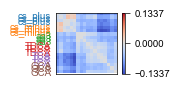

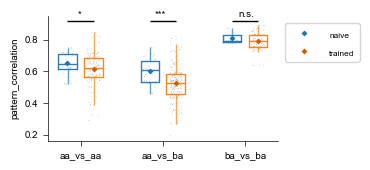

In [ ]:
from catrace.run.run_pattern_similarity import run_pattern_similarity, RunPatternSimilarityParams, PlotPatternSimilarityParams
from catrace.visualize import PlotPerCondMatParams, PlotBoxplotMultiOdorCondParams
from matplotlib.colors import Normalize, PowerNorm
plot_params = PlotPatternSimilarityParams(
    per_cond = PlotPerCondMatParams(
        row_height=1.45,#1.35,
        col_width=1.45,#1.35,
        title_fontsize=7,
        ylabel_fontsize=7,
        ylabel_colors = None,
        ylabels = None,
        #cmap='magma_r',
        cmap='jet_r',
        clim=[0, 0.15],
        color_norm=None,#PowerNorm(gamma=1.7), # 1.6
        cbar_interval=0.1,
        colorbar_fontsize=5,
    ),
    mean_delta = dict(
        figsize=(1.9, 1.9),
        colorbar_fontsize = 7,
        ylabel_fontsize = 7,
    ),
    vs_measure = PlotBoxplotMultiOdorCondParams(
        figsize=(3.8, 1.8),
        label_fontsize=7,
        show_ns=True,
        mean_marker_size=1,
        pvalue_marker_xoffset=0.04,
        box_linewidth=1,
        strip_alpha=0.8,
        strip_size=0.5,
        pvalue_bar_linewidth=1,
    )
)

params = RunPatternSimilarityParams(
    config_file = '../dataset_configs/juvenile_dataset_OB_t7.json',
    assembly_name = '',
    time_window = [38, 63],
    metric = 'cosine',#'pattern_correlation',
    overwrite_computation = False,
    do_plot_per_fish = False,
    do_plot_per_condition = True,
    do_save_cross_trial = True,
    do_reorder_cs=True,
    odor_orders = ['cs_plus', 'cs_minus', 'aa3', 'TDCA', 'TCA', 'GCA'],
    plot_params = plot_params,
    vsnames = ['aa_vs_aa', 'aa_vs_ba', 'ba_vs_ba'],
    manifold_level = 'odor',
)

if params.assembly_name == '':
    assembly_label = 'all_neurons'
else:
    assembly_label = params.assembly_name

window_tag = f'window_{params.time_window[0]}_{params.time_window[1]}'
sim_dir, output_figs, test_results, cross_trial_path = run_pattern_similarity(params)
print(cross_trial_path)

In [21]:
from os.path import join as pjoin
from catrace.for_paper import save_figure_for_paper
paper_fig_root_dir = '../../figures_for_paper'
dataset_name = 'juvenile_ob'
paper_fig_dir = pjoin(paper_fig_root_dir, dataset_name)

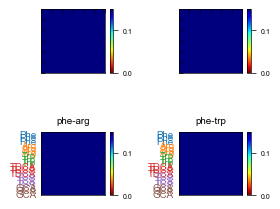

In [22]:
import copy
from matplotlib.ticker import MultipleLocator

def adjust_fig_per_cond(output_figs):
    fig_per_cond_copy = copy.deepcopy(output_figs['fig_per_cond'])
    ax = fig_per_cond_copy.get_axes()
    # Remove title for ax[0] and ax[1]
    ax[0].set_title('')
    ax[1].set_title('')
    # Delete y ticks
    # ax[0].set_yticks([])
    # ax[1].set_yticks([])
    # Delete y tick labels
    ax[0].set_yticklabels([])
    ax[1].set_yticklabels([])
    # put y ticks with interval of 3 using multiple locator
    ax[0].yaxis.set_major_locator(MultipleLocator(3))
    ax[1].yaxis.set_major_locator(MultipleLocator(3))
    # Get current y-ticks and adjust them to start at -0.5
    y_ticks_0 = ax[0].get_yticks()[1:]
    y_ticks_1 = ax[1].get_yticks()[1:]
    
    ax[0].set_yticks(y_ticks_0 - 0.5)
    ax[1].set_yticks(y_ticks_1 - 0.5)
    # Show y ticks
    ax[0].tick_params(axis='y', length=3, direction='in')
    ax[1].tick_params(axis='y', length=3, direction='in')

    # Do the same for x ticks
    ax[0].xaxis.set_major_locator(MultipleLocator(3))
    ax[1].xaxis.set_major_locator(MultipleLocator(3))
    x_ticks_0 = ax[0].get_xticks()[1:]
    x_ticks_1 = ax[1].get_xticks()[1:]
    ax[0].set_xticks(x_ticks_0 - 0.5)
    ax[1].set_xticks(x_ticks_1 - 0.5)
    ax[0].tick_params(axis='x', length=3, direction='in')
    ax[1].tick_params(axis='x', length=3, direction='in')
    ax[0].set_xticklabels([])
    ax[1].set_xticklabels([])
    # Put x ticks on top of the axes
    ax[0].xaxis.set_ticks_position('top')
    ax[1].xaxis.set_ticks_position('top')
    # # Delete colorbar on the first axes
    fig = fig_per_cond_copy
    # Keep arg-phe
    # fig.delaxes(fig.axes[2])
    # fig.delaxes(fig.axes[5])
    # fig.delaxes(fig.axes[2])
    # fig.delaxes(fig.axes[4])
    # fig.delaxes(fig.axes[2])
    fig_per_cond_copy.tight_layout()
    return fig_per_cond_copy

fig_per_cond_copy = adjust_fig_per_cond(output_figs)
save_figure_for_paper(fig_per_cond_copy, f'{dataset_name}_{params.metric}_{window_tag}per_cond', paper_fig_dir, save_eps=True)
fig_per_cond_copy

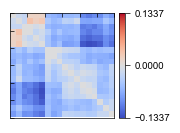

In [23]:
def adjust_ticks(ax):
    """
    Adjust the ticks of a single axes object.

    Parameters:
    - ax (matplotlib.axes.Axes): The axes object to be modified.
    """
    # Delete y tick labels
    ax.set_yticklabels([])
    
    # Set y ticks with an interval of 3 using MultipleLocator
    ax.yaxis.set_major_locator(MultipleLocator(3))
    
    # Get current y-ticks and adjust them to start at -0.5
    y_ticks = ax.get_yticks()[1:]
    ax.set_yticks(y_ticks - 0.5)
    
    # Show y ticks
    ax.tick_params(axis='y', length=3, direction='in')
    
    # Do the same for x ticks
    ax.xaxis.set_major_locator(MultipleLocator(3))
    x_ticks = ax.get_xticks()[1:]
    ax.set_xticks(x_ticks - 0.5)
    ax.tick_params(axis='x', length=3, direction='in')
    ax.xaxis.set_ticks_position('top')
    
    # Delete x tick labels
    ax.set_xticklabels([])


def adjust_fig_delta(output_figs):
    fig_delta_copy = copy.deepcopy(output_figs['fig_delta'])
    ax = fig_delta_copy.get_axes()
    adjust_ticks(ax[0])
    fig_delta_copy.tight_layout()
    return fig_delta_copy

fig_delta_copy = adjust_fig_delta(output_figs)
save_figure_for_paper(fig_delta_copy, f'{dataset_name}_{params.metric}_{window_tag}_mean_delta', paper_fig_dir)
fig_delta_copy

C:\Users\hubob\AppData\Local\Temp\ipykernel_37080\3487499702.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_xlabels)


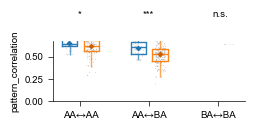

In [24]:
fig = output_figs['fig_multi_vs']
ax = fig.get_axes()[0]
ax.set_ylim((0, 0.68))
ylabel = ax.get_ylabel()
if ylabel=='cosine':
    new_ylabel = 'Cosine distance'
else:
    new_ylabel = ylabel
ax.set_ylabel(new_ylabel)

vslabel_mapping = {'aa_vs_aa': 'AA↔AA',
                   'aa_vs_ba': 'AA↔BA',
                   'ba_bs_aa': 'BA↔AA',
                   'ba_vs_ba': 'BA↔BA'}
xlabels = ax.get_xticklabels()
new_xlabels = [vslabel_mapping[label.get_text()] for label in xlabels]
ax.set_xticklabels(new_xlabels)
if ax.get_legend() is not None:
    ax.get_legend().remove()
# Change figure size
#fig.set_size_inches(2.8, 1.8)
fig.set_size_inches(2.6, 1.6)
fig.tight_layout()
save_figure_for_paper(output_figs['fig_multi_vs'], f'{dataset_name}_{params.metric}_{window_tag}_multi_vs', paper_fig_dir)
output_figs['fig_multi_vs']

In [25]:
from catrace.stats import format_test_results_multi_odor_two_cond
sentence = format_test_results_multi_odor_two_cond(test_results)
sentence = sentence.replace('aa_vs_aa', 'AvsA').replace('aa_vs_ba', 'AvsB').replace('ba_vs_aa', 'BvsA').replace('ba_vs_ba', 'BvsB')
print(sentence)

For AvsA, Comparing naive (mean = 0.65 ± 0.0694, n = 36) vs trained (mean = 0.62 ± 0.104, n = 150): Mann–Whitney U test, U = 3272.00, P = 0.049. For AvsB, Comparing naive (mean = 0.60 ± 0.0808, n = 54) vs trained (mean = 0.53 ± 0.111, n = 225): Mann–Whitney U test, U = 8657.00, P = 1.2 × 10^-6. For BvsB, Comparing naive (mean = 0.81 ± 0.0334, n = 24) vs trained (mean = 0.79 ± 0.0558, n = 100): Mann–Whitney U test, U = 1456.00, P = 0.106.
